##### ***双向循环神经网络***
###### 在序列模型中，我们往往的假设目标是，给定一定的观测，对下一个输出进行预测。虽然这是一个常见场景，但是我们必须考虑其他场景，如一句话的下文往往会给出重要提示，这在进行填空时非常重要，也就是说我们的模型不能只关注上文，还需要考虑下文，所以引入了双向循环神经网络。
##### ***隐马尔科夫模型中的动态规划***
###### 假设存在一个隐变量模型，在任意时间步t，存在一个隐变量$h_t$，通过概率$P(x_t|h_t)$控制我们观测到的$x_t$，此外，我任意的隐变量也是有类似的形式得到的，这样的模型就是隐马尔科夫模型（HMM）。
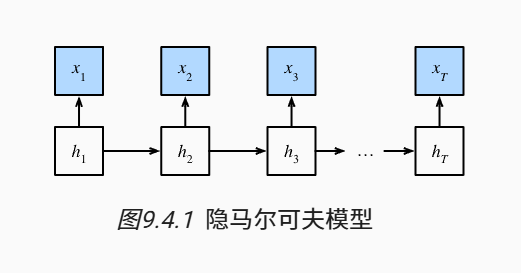
###### 由于HMM的假设：$h_t$只依赖于$h_{t-1}$，$x_t$只依赖于$h_t$，因此对于有T个观测值的序列，我们对于观测状态和隐状态有以下的联合概率分布：
$$P(x_1,x_2,...,x_T,h_1,h_2,...,h_T) = \prod_{t=1}^T P(h_t|h_{t-1})P(x_t|h_t), where P(h_1|h-0) = P(h_1)$$
###### 然而实际应用中我们往往观测不到隐变量$h_t$，只能观测观测状态$x_t$，因此我们需要消除掉隐变量$h_t$，只保留观测状态$x_t$。即，我们要求$P(x_1,x_2,...,x_T)$，所以我们要求在所有可能的$h_t$下的概率和，所以我们得到：
$$P(x_1,x_2,...,x_T) = \sum_{h_1,h_2,...,h_T} P(x_1,x_2,...,x_T,h_1,h_2,...,h_T) = \sum_{h_1,h_2,...,h_T} \prod_{t=1}^T P(h_t|h_{t-1})P(x_t|h_t)$$
###### 直接求解非常的困难，这里我们需要使用动态规划来求解。即，我们先求解$h_1$，然后根据$h_1$求解$h_2$，以此类推，直到$h_T$，最后根据$h_T$求解$x_T$。具体公式如下：
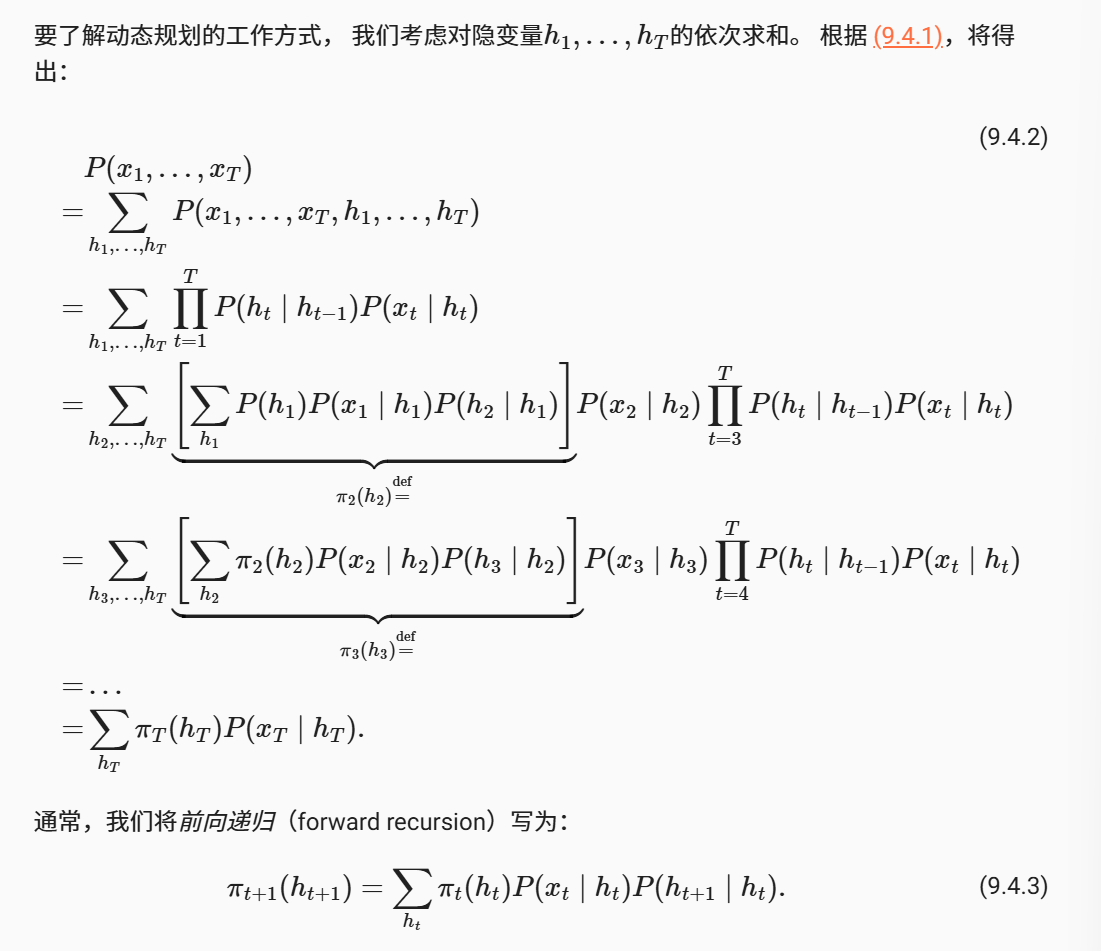
###### 同理，我们可以得到后向递归：
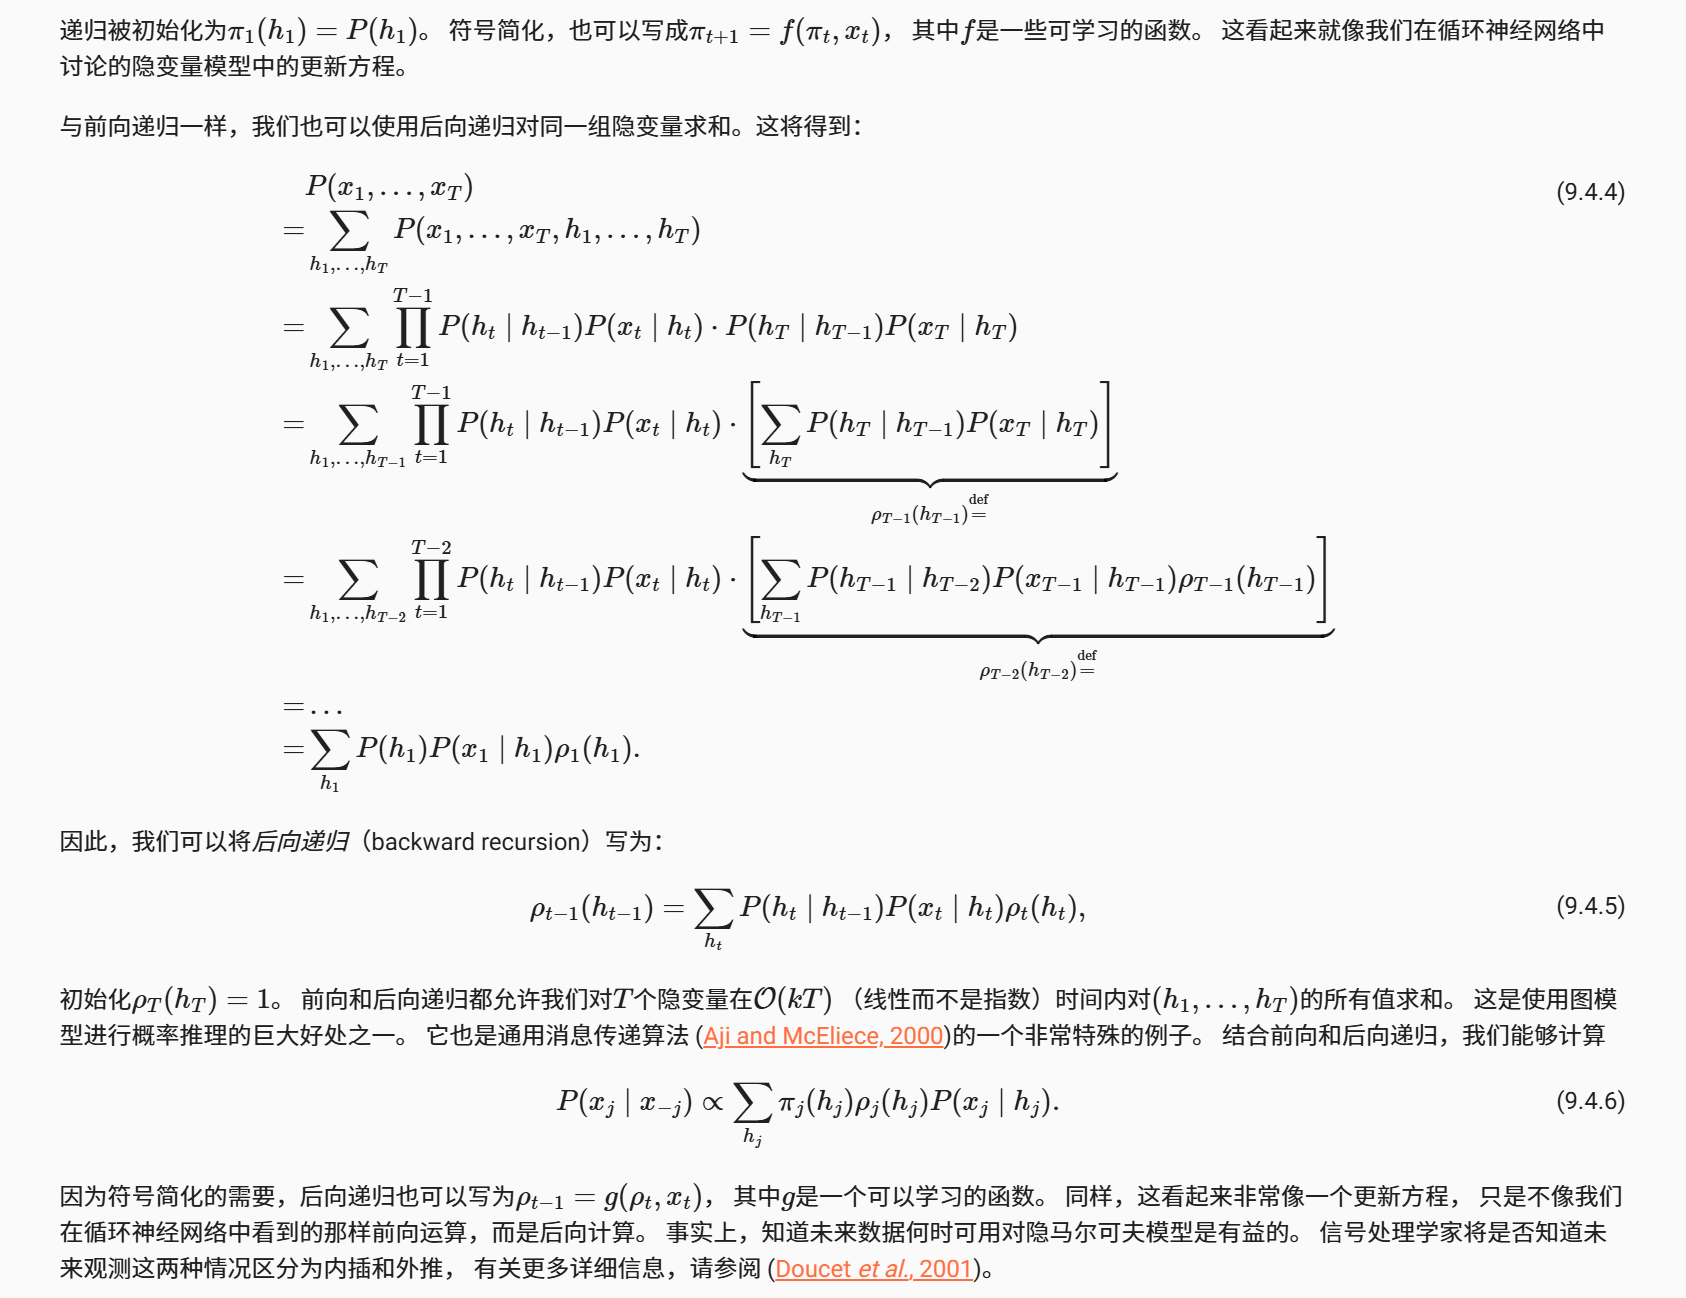
##### ***双向模型***
###### 如果我们希望在RNN中拥有一种类似于隐马尔科夫模型的前瞻能力，我们需要增加一个前向传播的RNN，这与上述的后向递归类似，具体结构如下图所示：
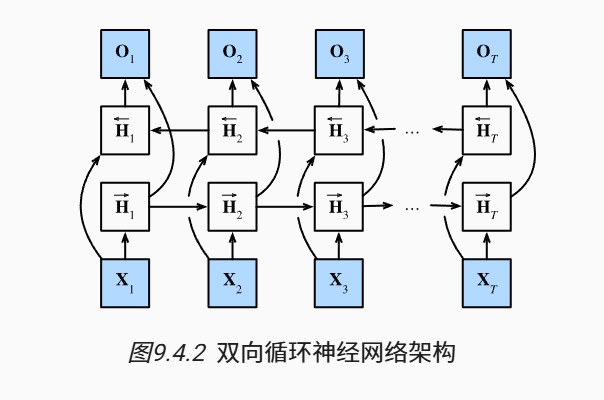
##### ***定义***
###### 为使有两种方向，所以我们定义前向和反向隐状态：$\overrightarrow{H}_t$和$\overleftarrow{H}_t$。具体定义如下：
$$\overrightarrow{H}_t = \sigma(X_tW_{xh}^{(f)} + \overrightarrow{H}_{t-1}W_{hh}^{(f)} + b_h^{(f)}),\\
\overleftarrow{H}_t = \sigma(X_tW_{xh}^{(b)} + \overleftarrow{H}_{t+1}W_{hh}^{(b)} + b_h^{(b)}),$$
###### 接着将前向隐状态和后向隐状态连接起来，获得需要送入输出层的隐状态$H_t\in \mathbb{R}^{n\times 2h}$，最终得到输出位：$O_t\in \mathbb{R}^{n\times q}$。
$$O_t = H_tW_{hq} + b_q.$$
###### 且这两个方向可以有不同的隐藏单元数。
##### ***局限性与应用***
###### 这样的双向RNN需要序列两端的信息估计输出，也就是说对于下一个词元预测的任务来说，这样的模型在训练时会表现很好，但是在测试中精度会大打折扣。<br>另一个严重的问题是双向RNN的训练时间会增加，因为需要从序列两端开始传播，这会导致模型的训练时间增加，由于是递归计算，所以训练会非常慢。<br>它的应用场合也因为非常的少：如填充缺失的单词，词元注释，对序列进行编码。

perplexity 1.1, 13457.1 tokens/sec on cpu
time travellerererererererererererererererererererererererererer
travellerererererererererererererererererererererererererer


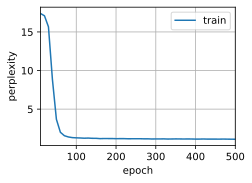

In [1]:
# 双向循环神经网络的错误应用
import torch
from torch import nn
from d2l import torch as d2l

# 加载数据
batch_size, num_steps, device = 32, 35, d2l.try_gpu()
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)
# 通过设置“bidirective=True”来定义双向LSTM模型
vocab_size, num_hiddens, num_layers = len(vocab), 256, 2
num_inputs = vocab_size
lstm_layer = nn.LSTM(num_inputs, num_hiddens, num_layers, bidirectional=True)
model = d2l.RNNModel(lstm_layer, len(vocab))
model = model.to(device)
# 训练模型
num_epochs, lr = 500, 1
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)